In [1]:
# Standard libraries
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

POS_COLORS = {'GK': '#f4a261', 'DEF': '#2a9d8f', 'MID': '#e9c46a', 'FWD': '#e76f51'}

In [3]:
preds = pd.read_csv(project_root / 'outputs' / 'predictions' / 'predictions_gw35_to_gw38.csv')

# Predictions use 2025-26 team IDs (current season run-in)
teams_df = pd.read_csv(project_root / 'data' / 'raw' / '2025-26' / 'teams.csv')
team_map = dict(zip(teams_df['id'], teams_df['short_name']))
preds['team_short'] = preds['team'].map(team_map).fillna(preds['team'].astype(str))

# A player can have 2 fixtures in one GW (double gameweek) -> 2 rows per (element, gw).
# Flag those because they materially boost transfer value.
fix_per_gw = preds.groupby(['element', 'gw']).size().rename('fix_in_gw').reset_index()
preds = preds.merge(fix_per_gw, on=['element', 'gw'])

n_dgw = (fix_per_gw['fix_in_gw'] > 1).sum()
print(f"Predictions: {len(preds)} rows, GWs {sorted(preds['gw'].unique())}, players: {preds['element'].nunique()}")
print(f"Double-gameweek occurrences: {n_dgw}")
preds.head()

Predictions: 3402 rows, GWs [np.int64(35), np.int64(36), np.int64(37), np.int64(38)], players: 830
Double-gameweek occurrences: 82


,element,name,position_label,team,gw,predicted_points,was_home,opponent_difficulty,has_fixture,team_short,fix_in_gw
0,515,Gibbs-White,MID,16,35,8.390056,0.0,3.0,True,NFO,1
1,691,Calvert-Lewin,FWD,11,35,6.484694,1.0,1.0,True,LEE,1
2,5,Gabriel,DEF,1,35,5.568955,1.0,3.0,True,ARS,1
3,449,B.Fernandes,MID,14,35,5.337093,1.0,3.0,True,MUN,1
4,1,Raya,GK,1,35,5.326446,1.0,3.0,True,ARS,1


In [4]:
# Per-player aggregation across the GW35-38 window
player_tot = (
    preds.groupby(['element', 'name', 'position_label', 'team', 'team_short'], as_index=False)
         .agg(total_points=('predicted_points', 'sum'),
              avg_points=('predicted_points', 'mean'),
              best_gw=('predicted_points', 'max'),
              worst_gw=('predicted_points', 'min'),
              n_fixtures=('predicted_points', 'size'))
         .sort_values('total_points', ascending=False)
         .reset_index(drop=True)
)
player_tot['label'] = player_tot['name'] + ' (' + player_tot['team_short'] + ')'
player_tot.head(20)

,element,name,position_label,team,team_short,total_points,avg_points,best_gw,worst_gw,n_fixtures,label
0,515,Gibbs-White,MID,16,NFO,33.551071,8.387768,8.922226,7.316564,4,Gibbs-White (NFO)
1,430,Haaland,FWD,13,MCI,27.829745,5.565949,6.175878,4.463208,5,Haaland (MCI)
2,260,Guéhi,DEF,13,MCI,23.081397,4.616279,4.939524,3.816385,5,Guéhi (MCI)
3,82,Semenyo,MID,13,MCI,22.934826,4.586965,5.028926,3.488608,5,Semenyo (MCI)
4,416,Bernardo,MID,13,MCI,22.846301,4.569260,4.836724,3.958477,5,Bernardo (MCI)
5,691,Calvert-Lewin,FWD,11,LEE,21.876625,5.469156,6.484694,5.115980,4,Calvert-Lewin (LEE)
6,624,Bowen,FWD,19,WHU,20.822608,5.205652,5.842118,4.720869,4,Bowen (WHU)
7,1,Raya,GK,1,ARS,20.756872,5.189218,5.661005,4.884710,4,Raya (ARS)
8,5,Gabriel,DEF,1,ARS,20.687995,5.171999,6.210237,4.454402,4,Gabriel (ARS)
9,407,Matheus N.,DEF,13,MCI,19.774352,3.954870,4.232707,3.213674,5,Matheus N. (MCI)


## 1. Top 30 players for the run-in (GW35–38)
Total predicted points across the remaining gameweeks. Best overall transfer targets.

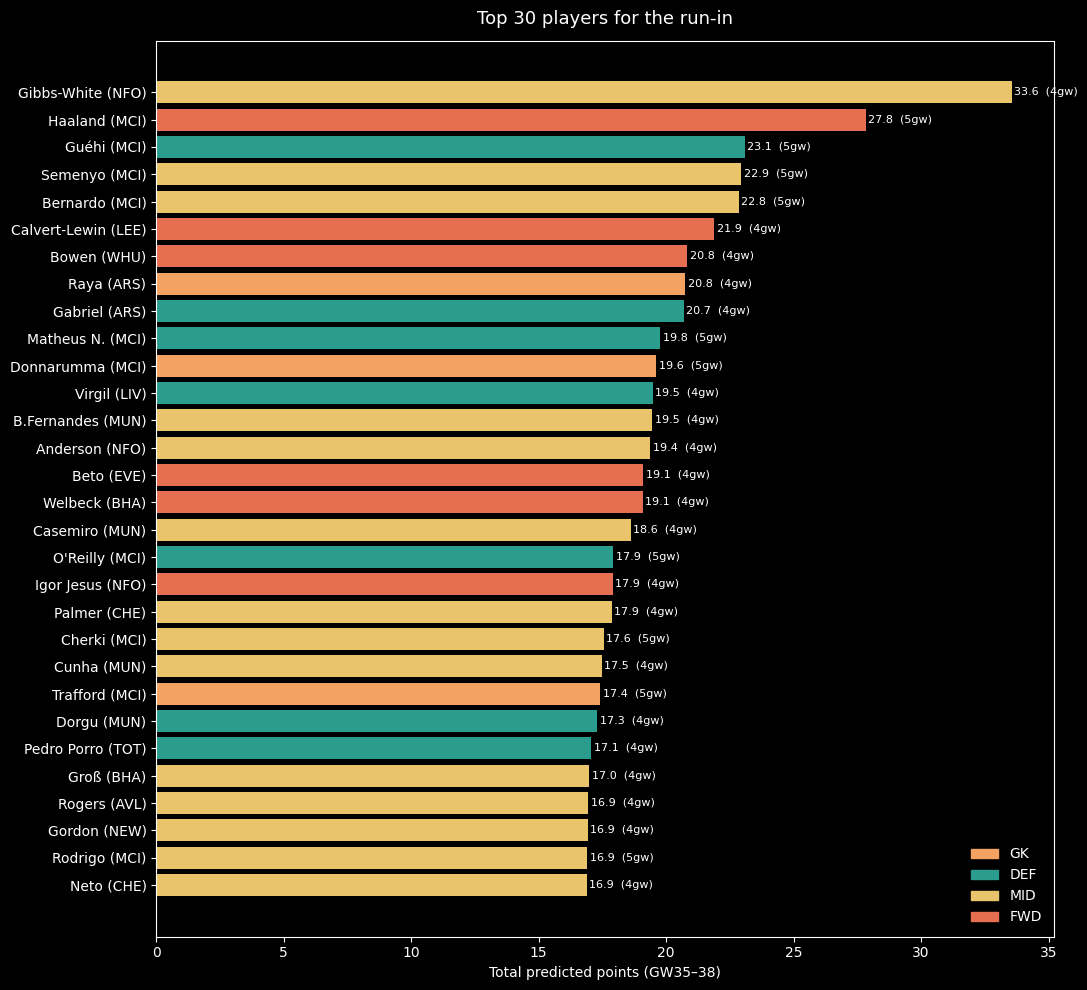

In [5]:
top_n = 30
top = player_tot.head(top_n).iloc[::-1]  # reverse for horizontal bar (highest at top)

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(top['label'], top['total_points'],
               color=[POS_COLORS[p] for p in top['position_label']])
for bar, val, n in zip(bars, top['total_points'], top['n_fixtures']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}  ({n}gw)', va='center', fontsize=8)
ax.set_xlabel('Total predicted points (GW35–38)')
ax.set_title(f'Top {top_n} players for the run-in', fontsize=13, pad=12)
ax.legend(handles=[mpatches.Patch(color=c, label=p) for p, c in POS_COLORS.items()],
          loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'figures' / 'top30_run_in.png', dpi=130)
plt.show()

## 2. Run-in heatmap (top 25 × gameweek)
Spot good fixture runs vs blanks. Bright = high predicted points; dark = low / no fixture.

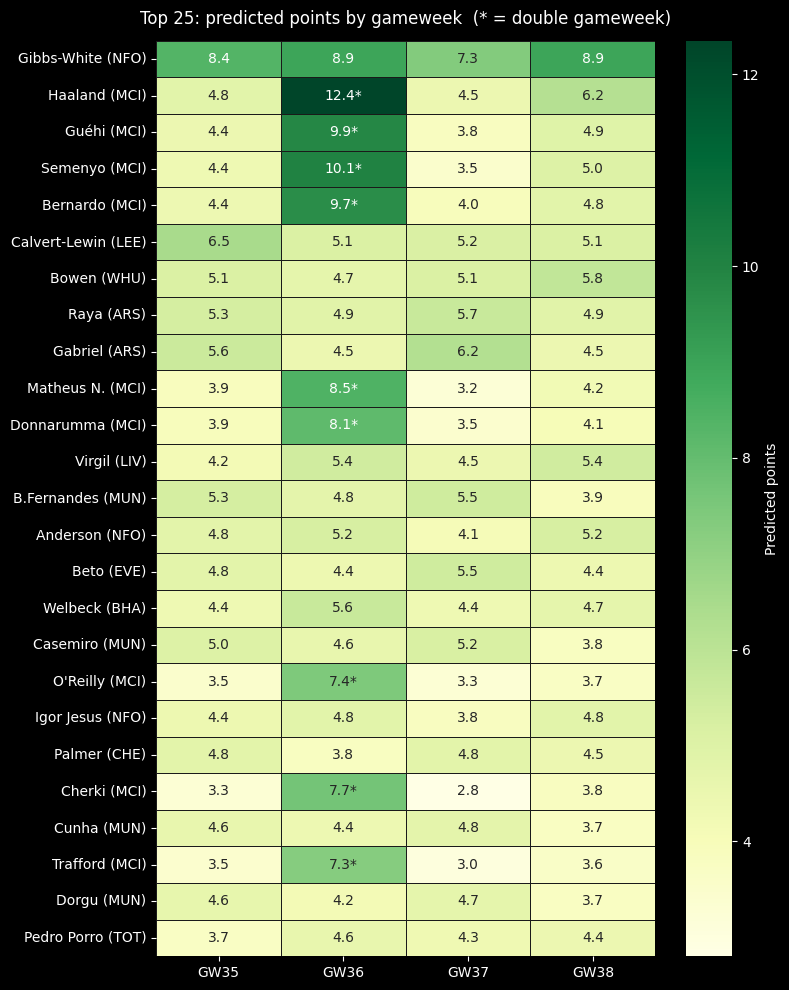

In [6]:
top_n = 25
top_players = player_tot.head(top_n)
mat = (preds[preds['element'].isin(top_players['element'])]
       .pivot_table(index='element', columns='gw', values='predicted_points', aggfunc='sum')
       .reindex(top_players['element']))
labels = [f"{n} ({t})" for n, t in zip(top_players['name'], top_players['team_short'])]

# Mark DGWs in the cell text (e.g. "8.4*")
dgw_mask = (preds[preds['element'].isin(top_players['element'])]
            .pivot_table(index='element', columns='gw', values='fix_in_gw', aggfunc='max')
            .reindex(top_players['element']))
annot = mat.copy().astype(object)
for i, idx in enumerate(mat.index):
    for j, col in enumerate(mat.columns):
        v = mat.iat[i, j]
        if pd.isna(v):
            annot.iat[i, j] = '-'
        else:
            star = '*' if dgw_mask.iat[i, j] and dgw_mask.iat[i, j] > 1 else ''
            annot.iat[i, j] = f'{v:.1f}{star}'

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(mat.values, annot=annot.values, fmt='', cmap='YlGn',
            xticklabels=[f'GW{g}' for g in mat.columns], yticklabels=labels,
            cbar_kws={'label': 'Predicted points'}, linewidths=0.4, linecolor='#1a1a1a',
            ax=ax)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title(f'Top {top_n}: predicted points by gameweek  (* = double gameweek)',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'figures' / 'run_in_heatmap.png', dpi=130)
plt.show()

## 3. Top 10 by position
Pick a target by the slot you need to fill (GK / DEF / MID / FWD).

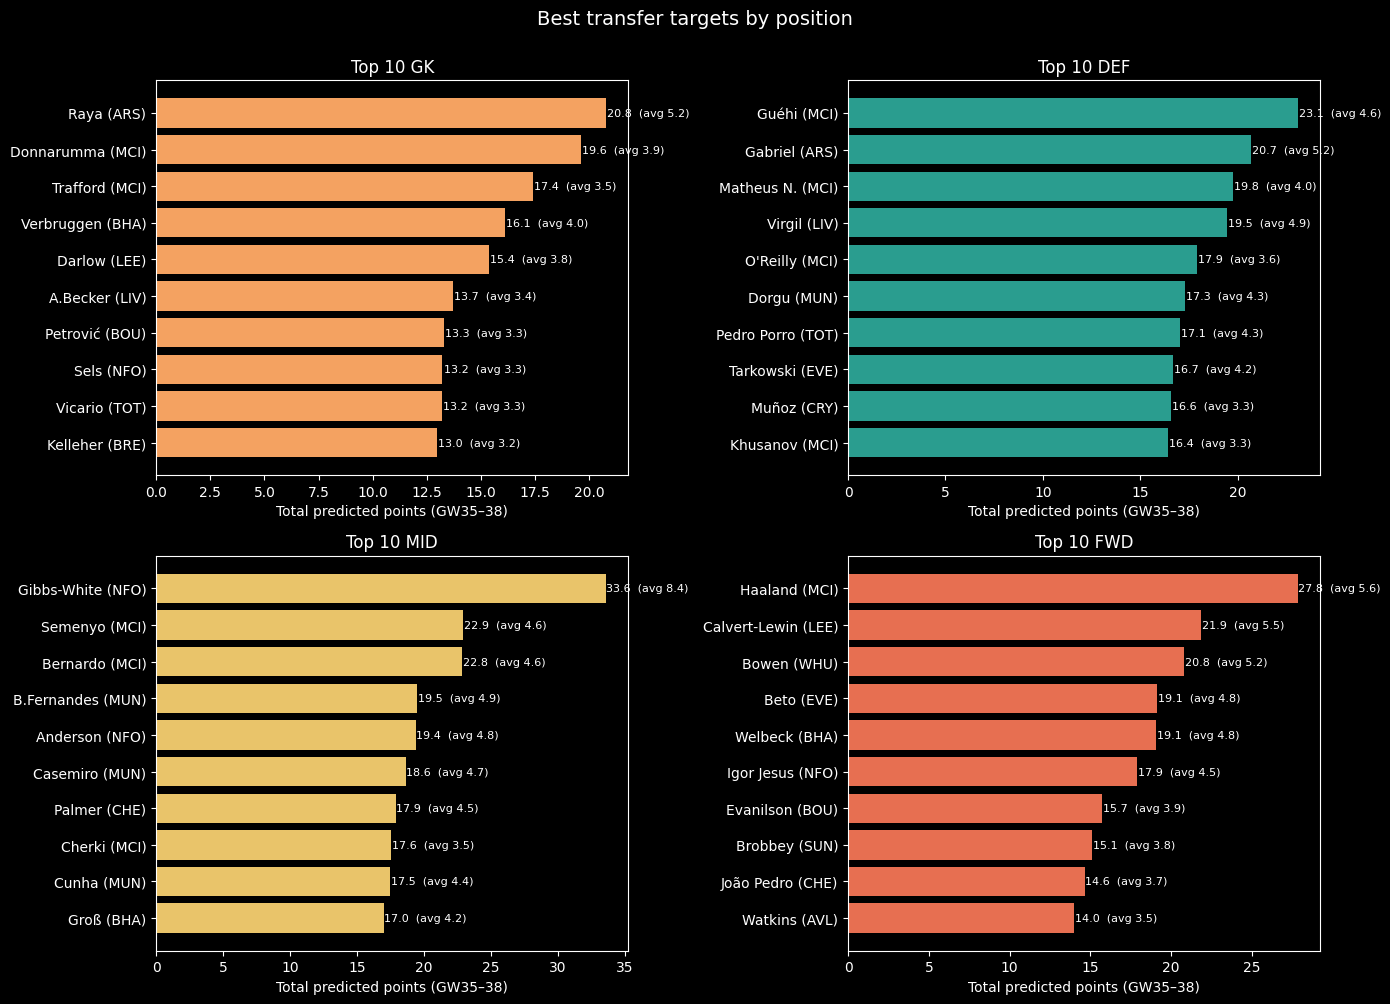

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, pos in zip(axes.flat, ['GK', 'DEF', 'MID', 'FWD']):
    sub = player_tot[player_tot['position_label'] == pos].head(10).iloc[::-1]
    bars = ax.barh(sub['label'], sub['total_points'], color=POS_COLORS[pos])
    for bar, v, avg in zip(bars, sub['total_points'], sub['avg_points']):
        ax.text(v + 0.05, bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}  (avg {avg:.1f})', va='center', fontsize=8)
    ax.set_title(f'Top 10 {pos}', fontsize=12)
    ax.set_xlabel('Total predicted points (GW35–38)')
fig.suptitle('Best transfer targets by position', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'figures' / 'top_by_position.png', dpi=130)
plt.show()

## 4. Captain options per gameweek
Highest predicted scorer in each individual GW — useful for armband / chip planning.

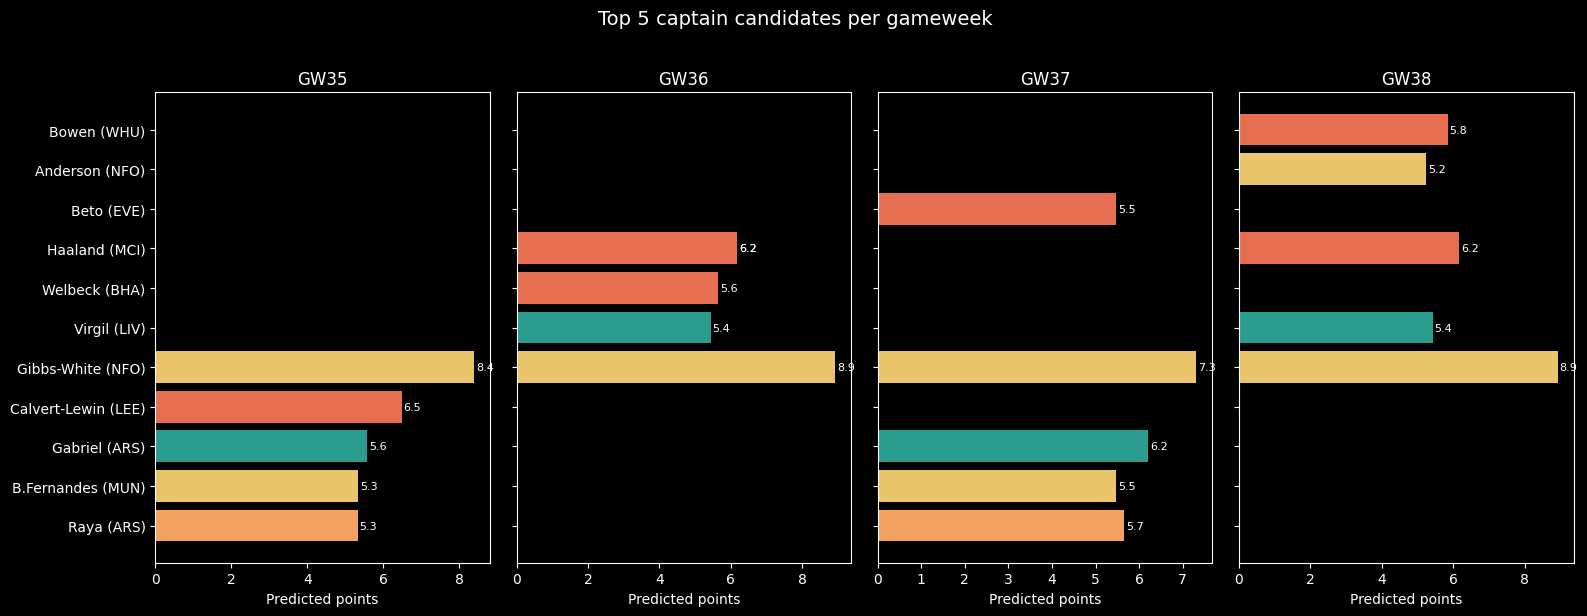

In [8]:
n_per_gw = 5
caps = (preds.sort_values('predicted_points', ascending=False)
             .groupby('gw').head(n_per_gw)
             .sort_values(['gw', 'predicted_points'], ascending=[True, False])
             .reset_index(drop=True))

gws = sorted(preds['gw'].unique())
fig, axes = plt.subplots(1, len(gws), figsize=(4 * len(gws), 6), sharey=True)
for ax, g in zip(axes, gws):
    sub = caps[caps['gw'] == g].iloc[::-1]
    bars = ax.barh([f"{n} ({t})" for n, t in zip(sub['name'], sub['team_short'])],
                   sub['predicted_points'],
                   color=[POS_COLORS[p] for p in sub['position_label']])
    for bar, v in zip(bars, sub['predicted_points']):
        ax.text(v + 0.05, bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}', va='center', fontsize=8)
    ax.set_title(f'GW{g}', fontsize=12)
    ax.set_xlabel('Predicted points')
fig.suptitle(f'Top {n_per_gw} captain candidates per gameweek', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'figures' / 'captain_options.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Full per-player table (sortable)
Use this to compare candidates head-to-head.

In [9]:
# Wide view: one row per player, one column per GW.
# Use pivot_table + sum so double-gameweeks combine into a single GW column.
wide = (preds.pivot_table(index=['element', 'name', 'position_label', 'team_short'],
                          columns='gw', values='predicted_points', aggfunc='sum')
             .reset_index())
wide.columns = [f'GW{c}' if isinstance(c, (int, np.integer)) else c for c in wide.columns]
gw_cols = [c for c in wide.columns if str(c).startswith('GW')]
wide['total'] = wide[gw_cols].sum(axis=1)
wide['avg']   = wide[gw_cols].mean(axis=1)
wide = wide.sort_values('total', ascending=False).reset_index(drop=True)

wide.head(50).round(2)

,element,name,position_label,team_short,GW35,GW36,GW37,GW38,total,avg
0,515,Gibbs-White,MID,NFO,8.39,8.92,7.32,8.92,33.55,8.39
1,430,Haaland,FWD,MCI,4.84,12.35,4.46,6.18,27.83,6.96
2,260,Guéhi,DEF,MCI,4.45,9.88,3.82,4.94,23.08,5.77
3,82,Semenyo,MID,MCI,4.36,10.06,3.49,5.03,22.93,5.73
4,416,Bernardo,MID,MCI,4.38,9.67,3.96,4.84,22.85,5.71
5,691,Calvert-Lewin,FWD,LEE,6.48,5.12,5.16,5.12,21.88,5.47
6,624,Bowen,FWD,WHU,5.13,4.72,5.13,5.84,20.82,5.21
7,1,Raya,GK,ARS,5.33,4.88,5.66,4.88,20.76,5.19
8,5,Gabriel,DEF,ARS,5.57,4.45,6.21,4.45,20.69,5.17
9,407,Matheus N.,DEF,MCI,3.86,8.47,3.21,4.23,19.77,4.94
